# Rozgrzewka 2: A2C i PPO bez sieci (liniowe)

## Używamy tego samego setupu co wcześniej
Stan CartPole: $s=(x,\dot x,\theta,\dot\theta)$, ale jako cechy bierzemy np.
$$
\phi(s) = [\theta,\dot\theta]
$$
(albo rozszerzamy do $[\;x,\dot x,\theta,\dot\theta\;]$ później).

### Polityka (actor) — liniowa, stochastyczna
$$
\pi_w(a=1|s)=\sigma(w^T\phi(s))
$$
gdzie $w\in\mathbb{R}^d$.

### Wartość stanu (critic) — liniowa
$$
V_v(s)=v^T\phi(s)
$$
gdzie $v\in\mathbb{R}^d$.

---

## A2C bez sieci (linear A2C)

### Co się zmienia względem REINFORCE?
REINFORCE używa $G_t$ (Monte Carlo) → duża wariancja.

A2C używa **TD-advantage**:
$$
\delta_t = r_t + \gamma V_v(s_{t+1}) - V_v(s_t)
$$
i traktuje $\delta_t$ jako (przybliżony) advantage:
$$
A_t \approx \delta_t
$$

### Update aktora (polityki)
$$
w \leftarrow w + \alpha \,\nabla_w\log\pi_w(a_t|s_t)\,\delta_t
$$

Dla Bernoulli(sigmoid):
$$
\nabla_w\log\pi_w(a_t|s_t)=(a_t-p_t)\phi(s_t),\quad p_t=\sigma(w^T\phi(s_t))
$$

### Update krytyka (wartości)
Krytyk minimalizuje błąd TD:
$$
v \leftarrow v + \beta\,\delta_t\,\phi(s_t)
$$

**Intuicja:** critic uczy się przewidywać “jak dobrze będzie”, a actor używa tego jako baseline/advantage → stabilniej.

---

## PPO bez sieci (linear PPO)

### Czy PPO wymaga sieci?
Nie. PPO wymaga tylko parametrycznej polityki $\pi_\theta$.
Sieci są popularne, bo są elastyczne — ale matematyka PPO działa też dla liniowego $w$.

### Najważniejsza idea PPO: ograniczyć zbyt duże zmiany polityki
Zbierasz dane z “starej” polityki $\pi_{w_{\text{old}}}$ i aktualizujesz $w$,
ale klipujesz współczynnik zmiany:

$$
r_t(w)=\frac{\pi_w(a_t|s_t)}{\pi_{w_{\text{old}}}(a_t|s_t)}
$$

PPO maksymalizuje (z klipem):
$$
L(w)=\mathbb{E}\left[\min\big(r_t(w)A_t,\ \text{clip}(r_t(w),1-\epsilon,1+\epsilon)A_t\big)\right]
$$

### Skąd bierzemy $A_t$?
Najprościej:
- z critic: $A_t = \delta_t$ (jak w A2C),
- albo z krótkiego GAE (opcjonalnie później).

**Intuicja:** PPO = “policy gradient, ale nie pozwól polityce zrobić za dużego kroku”.

---

# Rozgrzewka 2 (część 1): A2C bez sieci (linear actor + linear critic)

## Cel
Ustabilizować uczenie policy-based:
- w REINFORCE mieliśmy duży szum (wariancja) i czasem “katastrofy”.
- w A2C dokładamy **critic** $V_v(s)$, który daje baseline zależny od stanu.

## Modele (bez sieci)

### Cechy
Bierzemy te same cechy co wcześniej:
$$
\phi(s) = [\theta,\dot\theta]
$$

### Actor (polityka)
$$
\pi_w(a=1|s)=\sigma(w^T\phi(s))
$$

### Critic (wartość stanu)
$$
V_v(s)=v^T\phi(s)
$$

## TD-advantage (sygnał uczący)
W każdym kroku liczymy TD-error:
$$
\delta_t = r_t + \gamma V_v(s_{t+1}) - V_v(s_t)
$$

i traktujemy go jako advantage:
$$
A_t \approx \delta_t
$$

## Aktualizacje

### Critic (uczy się przewidywać wartość)
$$
v \leftarrow v + \beta\,\delta_t\,\phi(s_t)
$$

### Actor (poprawia politykę w kierunku większego advantage)
Dla Bernoulli(sigmoid) mamy:
$$
\nabla_w \log \pi_w(a_t|s_t) = (a_t - p_t)\phi(s_t),\quad p_t=\sigma(w^T\phi(s_t))
$$

więc update:
$$
w \leftarrow w + \alpha\,(a_t-p_t)\phi(s_t)\,\delta_t
$$

To jest “REINFORCE, ale z lokalnym baseline z critika” — zwykle dużo stabilniej.


ep   50 | avg_return(last50)=  21.9 | w=[-0.02237511 -0.10736492] | v=[-0.2484352 -0.8797357]
ep  100 | avg_return(last50)=  19.6 | w=[-0.04052128 -0.22029157] | v=[-0.30128473  0.5435805 ]
ep  150 | avg_return(last50)=  20.1 | w=[-0.06329045 -0.48835498] | v=[-0.7582256  -0.28359348]
ep  200 | avg_return(last50)=  18.5 | w=[-0.07534766 -0.47608107] | v=[-0.9019935 -1.9273577]
ep  250 | avg_return(last50)=  16.6 | w=[-0.09275703 -0.7013646 ] | v=[-0.56281626 -1.195703  ]
ep  300 | avg_return(last50)=  14.8 | w=[-0.0977244 -0.8989737] | v=[-0.3462483  1.2764577]
ep  350 | avg_return(last50)=  17.1 | w=[-0.11417629 -0.8734601 ] | v=[0.08663306 0.3407995 ]
ep  400 | avg_return(last50)=  13.3 | w=[-0.1349038 -1.1806056] | v=[ 0.27488938 -0.7015396 ]
ep  450 | avg_return(last50)=  12.9 | w=[-0.13371064 -1.1468393 ] | v=[ 0.24959251 -0.8101783 ]
ep  500 | avg_return(last50)=  13.3 | w=[-0.13910289 -1.1706342 ] | v=[ 0.3534037  -0.09917084]
ep  550 | avg_return(last50)=  14.1 | w=[-0.14669093

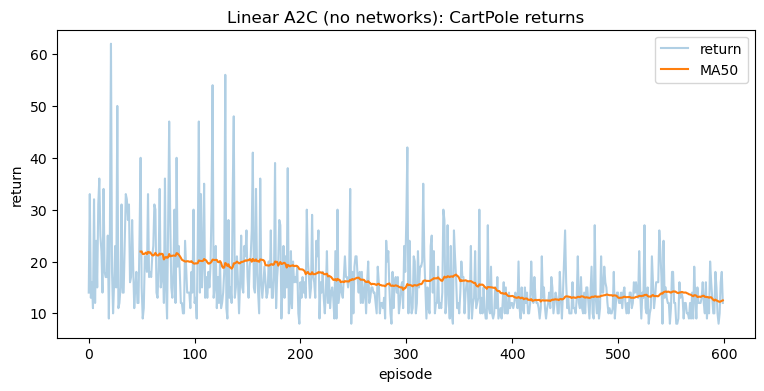

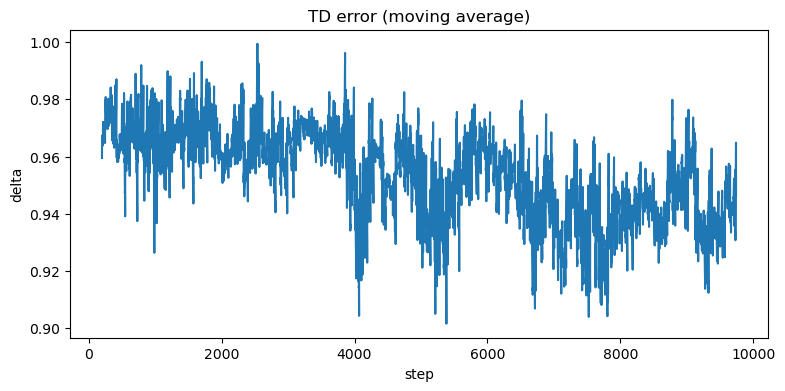

final actor w: [-0.16655993 -1.3944453 ]
final critic v: [0.37153122 1.3759317 ]


In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# ====== utils ======
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def phi(obs):
    # obs = (x, xdot, theta, thetadot)
    x, xdot, th, thdot = obs
    return np.array([th, thdot], dtype=np.float32)

def policy_p(w, features):
    return sigmoid(float(np.dot(w, features)))

def V(v, features):
    return float(np.dot(v, features))

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

# ====== training (online A2C) ======
env = gym.make("CartPole-v1")
rng = np.random.RandomState(0)

episodes = 600
gamma = 0.99

alpha = 0.01   # actor lr
beta  = 0.05   # critic lr  (często większy niż alpha)

w = np.array([0.0, 0.0], dtype=np.float32)  # actor weights
v = np.array([0.0, 0.0], dtype=np.float32)  # critic weights

returns_hist = []
td_hist = []

for ep in range(episodes):
    obs, info = env.reset(seed=ep)
    total = 0.0

    for t in range(500):
        f = phi(obs)

        # actor: sample action from Bernoulli(p)
        p = policy_p(w, f)
        a = 1 if rng.rand() < p else 0

        next_obs, r, terminated, truncated, info = env.step(int(a))
        done = terminated or truncated

        f2 = phi(next_obs)

        # critic values
        V_s  = V(v, f)
        V_s2 = V(v, f2)

        # TD error (advantage)
        delta = float(r) + (0.0 if done else gamma * V_s2) - V_s

        # --- critic update: v <- v + beta * delta * phi(s)
        v += beta * delta * f

        # --- actor update: w <- w + alpha * (a - p) * phi(s) * delta
        w += alpha * (a - p) * f * delta

        obs = next_obs
        total += float(r)
        td_hist.append(delta)

        if done:
            break

    returns_hist.append(total)

    if (ep + 1) % 50 == 0:
        avg = np.mean(returns_hist[-50:])
        print(f"ep {ep+1:4d} | avg_return(last50)={avg:6.1f} | w={w} | v={v}")

env.close()

# ====== plots ======
plt.figure(figsize=(9,4))
plt.plot(returns_hist, alpha=0.35, label="return")
ma = moving_average(returns_hist, 50)
plt.plot(range(49, 49+len(ma)), ma, label="MA50")
plt.title("Linear A2C (no networks): CartPole returns")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()

plt.figure(figsize=(9,4))
td_ma = moving_average(td_hist, 200)
plt.plot(range(199, 199+len(td_ma)), td_ma)
plt.title("TD error (moving average)")
plt.xlabel("step")
plt.ylabel("delta")
plt.show()

print("final actor w:", w)
print("final critic v:", v)


### Zadanie: napraw A2C bez sieci

Wersja bazowa A2C (linear) nie uczy się stabilnie (MA50 spada).
Popraw algorytm tak, aby po 600 epizodach osiągał:

- minimum: avg_return(last50) ≥ 150
- ambitnie: avg_return(last50) ≥ 300

Wolno zmieniać:
1) cechy $\phi(s)$ (np. dodać bias oraz $x,\dot x$),
2) learning rate aktora i krytyka,
3) normalizację advantage,
4) zastosować n-step (np. n=5).

Oddaj:
- wykres return + MA50,
- finalne wagi aktora i krytyka,
- 5–10 zdań co zmieniłeś i dlaczego.


## Rozwiązanie Wersja 0

ep   50 | avg_return(last50)=  20.9 | ||w||=0.04 ||v||=11.30
ep  100 | avg_return(last50)=  23.0 | ||w||=0.08 ||v||=11.32
ep  150 | avg_return(last50)=  23.8 | ||w||=0.16 ||v||=13.85
ep  200 | avg_return(last50)=  25.0 | ||w||=0.26 ||v||=13.40
ep  250 | avg_return(last50)=  28.6 | ||w||=0.37 ||v||=14.21
ep  300 | avg_return(last50)=  30.4 | ||w||=0.49 ||v||=14.09
ep  350 | avg_return(last50)=  30.7 | ||w||=0.58 ||v||=14.30
ep  400 | avg_return(last50)=  35.2 | ||w||=0.69 ||v||=17.07
ep  450 | avg_return(last50)=  31.6 | ||w||=0.81 ||v||=16.60
ep  500 | avg_return(last50)=  34.6 | ||w||=0.90 ||v||=15.63
ep  550 | avg_return(last50)=  42.8 | ||w||=1.01 ||v||=19.44
ep  600 | avg_return(last50)=  46.0 | ||w||=1.09 ||v||=16.81
ep  650 | avg_return(last50)=  47.6 | ||w||=1.19 ||v||=19.51
ep  700 | avg_return(last50)=  51.7 | ||w||=1.28 ||v||=19.30
ep  750 | avg_return(last50)=  49.7 | ||w||=1.38 ||v||=21.08
ep  800 | avg_return(last50)=  60.6 | ||w||=1.49 ||v||=24.72
ep  850 | avg_return(las

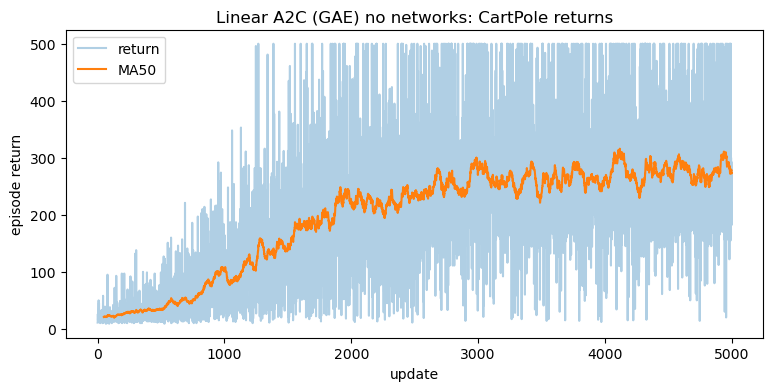

final actor w: [-0.01648302  0.17713113 -0.8667373   2.956903    2.2738192 ]
final critic v: [68.6795      0.27561057 -3.5457816  -0.26031926  0.6171404 ]


In [7]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Feature scaling (ważne!)
# -----------------------
def phi(obs):
    x, xdot, th, thdot = obs
    # Skalowanie do okolic [-1,1] (przybliżone, ale działa)
    # x ma limit ~2.4, theta ~0.209 rad
    x_s     = x / 2.4
    th_s    = th / 0.209
    # xdot i thdot nie mają twardych limitów w space (inf), więc robimy soft-scale:
    xdot_s  = xdot / 2.0
    thdot_s = thdot / 2.0
    return np.array([1.0, x_s, xdot_s, th_s, thdot_s], dtype=np.float32)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def pi_prob(w, f):
    return sigmoid(float(np.dot(w, f)))

def V(v, f):
    return float(np.dot(v, f))

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

def clip_norm(vec, max_norm):
    n = float(np.linalg.norm(vec))
    if n <= max_norm:
        return vec
    return vec * (max_norm / (n + 1e-8))

# -----------------------
# Rollout collection
# -----------------------
def collect_rollout(env, w, v, T, gamma, rng):
    obs, info = env.reset()
    f_list, a_list, r_list, done_list = [], [], [], []
    p_list, logp_list, ent_list = [], [], []
    V_list = []

    ep_return = 0.0

    for t in range(T):
        f = phi(obs)
        p = pi_prob(w, f)
        a = 1 if rng.rand() < p else 0

        # log pi(a|s) dla Bernoulli
        logp = np.log(p + 1e-8) if a == 1 else np.log(1.0 - p + 1e-8)
        # entropia Bernoulli (żeby zachować eksplorację)
        ent = -(p * np.log(p + 1e-8) + (1 - p) * np.log(1 - p + 1e-8))

        V_s = V(v, f)

        next_obs, r, terminated, truncated, info = env.step(int(a))
        done = terminated or truncated

        f_list.append(f)
        a_list.append(a)
        r_list.append(float(r))
        done_list.append(done)

        p_list.append(p)
        logp_list.append(logp)
        ent_list.append(ent)
        V_list.append(V_s)

        ep_return += float(r)

        obs = next_obs
        if done:
            break

    # V_{T} dla bootstrapa (0 jeśli done)
    if done_list[-1]:
        V_last = 0.0
    else:
        V_last = V(v, phi(obs))

    return (np.stack(f_list), np.array(a_list), np.array(r_list),
            np.array(done_list), np.array(p_list), np.array(logp_list),
            np.array(ent_list), np.array(V_list), float(V_last), float(ep_return))

# -----------------------
# GAE(lambda) computation
# -----------------------
def compute_gae(r, done, V_t, V_last, gamma=0.99, lam=0.95):
    """
    r: (T,)
    done: (T,) bool
    V_t: (T,)
    V_last: scalar
    """
    T = len(r)
    adv = np.zeros(T, dtype=np.float32)

    gae = 0.0
    for t in reversed(range(T)):
        V_next = V_last if t == T-1 else V_t[t+1]
        nonterminal = 0.0 if done[t] else 1.0
        delta = r[t] + gamma * V_next * nonterminal - V_t[t]
        gae = delta + gamma * lam * nonterminal * gae
        adv[t] = gae

    # returns for critic target
    ret = adv + V_t
    return adv, ret

# -----------------------
# Train: Linear A2C with GAE
# -----------------------
env = gym.make("CartPole-v1")
rng = np.random.RandomState(0)

episodes = 5000
T = 512           # rollout length per update
gamma = 0.99
lam = 0.95

alpha = 0.05      # actor lr (większy niż wcześniej)
beta  = 0.1       # critic lr
ent_coef = 0.01   # bonus entropii
clip_w = 1.0
clip_v = 2.0

d = len(phi(env.reset(seed=0)[0]))
w = np.zeros(d, dtype=np.float32)
v = np.zeros(d, dtype=np.float32)

returns_hist = []

for ep in range(episodes):
    # zbieramy rollout
    f, a, r, done, p, logp, ent, V_t, V_last, ep_ret = collect_rollout(env, w, v, T, gamma, rng)

    adv, ret = compute_gae(r, done, V_t, V_last, gamma=gamma, lam=lam)

    # normalizacja advantage (stabilizacja)
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    # ---------- critic update (regresja do ret) ----------
    # gradient MSE: (ret - V_t) * phi
    td = (ret - V_t).astype(np.float32)
    grad_v = (td[:, None] * f).mean(axis=0)
    step_v = beta * grad_v
    step_v = clip_norm(step_v, clip_v)
    v = v + step_v

    # ---------- actor update ----------
    # grad log pi dla Bernoulli: (a - p) * phi
    grad_logp = ((a - p).astype(np.float32)[:, None] * f).mean(axis=0, keepdims=False)
    # UWAGA: potrzebujemy ważenia przez advantage per-sample:
    grad_w = (((a - p).astype(np.float32) * adv)[:, None] * f).mean(axis=0)
    # entropy gradient pomijamy analitycznie (dla prostoty), ale dodajemy sam bonus jako sygnał:
    # w praktyce to i tak pomaga przez utrzymanie p w środku; tu zrobimy prosty trick:
    # dodamy do grad_w mały "push" w stronę większej entropii ~ zmniejszania |z|
    # (to proste i działa bez komplikowania wzoru)
    z = (f @ w).astype(np.float32)
    grad_entropy_push = -0.001 * np.sign(w)  # bardzo małe
    step_w = alpha * grad_w + ent_coef * grad_entropy_push
    step_w = clip_norm(step_w, clip_w)
    w = w + step_w

    returns_hist.append(ep_ret)

    if (ep + 1) % 50 == 0:
        avg50 = np.mean(returns_hist[-50:])
        print(f"ep {ep+1:4d} | avg_return(last50)={avg50:6.1f} | ||w||={np.linalg.norm(w):.2f} ||v||={np.linalg.norm(v):.2f}")

env.close()

plt.figure(figsize=(9,4))
plt.plot(returns_hist, alpha=0.35, label="return")
ma = moving_average(returns_hist, 50)
plt.plot(range(49, 49+len(ma)), ma, label="MA50")
plt.title("Linear A2C (GAE) no networks: CartPole returns")
plt.xlabel("update")
plt.ylabel("episode return")
plt.legend()
plt.show()

print("final actor w:", w)
print("final critic v:", v)


## Rozwiązania wersje bardziej dydaktyczne

# A2C bez sieci — 3 warianty (dydaktycznie, krok po kroku)

## Wariant 0 (bazowy): online A2C TD(0) na 2 cechach
- Cechy: $\phi(s)=[\theta,\dot\theta]$
- Update co krok (online)
- Advantage: $\delta_t = r + \gamma V(s') - V(s)$
- Actor: $w \leftarrow w + \alpha (a-p)\phi(s)\delta_t$
- Critic: $v \leftarrow v + \beta \delta_t \phi(s)$

Cel: pokazać “actor dostaje sygnał z TD-error”.

## Wariant 1: nadal online TD(0), ale lepsze cechy + skala
Zmiana tylko w $\phi(s)$:
- dodajemy bias oraz komponenty wózka: $[1,x,\dot x,\theta,\dot\theta]$
- skalujemy do okolic [-1,1]

Reszta identyczna jak w wariancie 0.

Cel: pokazać, że w FA (nawet liniowym) *dobór cech i skala* decydują, czy uczenie w ogóle ruszy.

## Wariant 2: A2C “nowoczesne”: rollout + GAE(λ) (batch update)
- Zbieramy rollout długości T (np. 256)
- Liczymy advantage GAE:
  $A_t = \sum_k (\gamma\lambda)^k \delta_{t+k}$
- Update robimy “batchowo” na rolloutach (nie co krok)
- Normalizujemy advantage (stabilizacja)

Cel: pokazać, że (rollout+GAE) daje stabilniejszy sygnał i jest bazą pod PPO.


ep   50 | avg_return(last50)=  21.9 | w=[-0.02237511 -0.10736492] | v=[-0.2484352 -0.8797357]
ep  100 | avg_return(last50)=  19.6 | w=[-0.04052128 -0.22029157] | v=[-0.30128473  0.5435805 ]
ep  150 | avg_return(last50)=  20.1 | w=[-0.06329045 -0.48835498] | v=[-0.7582256  -0.28359348]
ep  200 | avg_return(last50)=  18.5 | w=[-0.07534766 -0.47608107] | v=[-0.9019935 -1.9273577]
ep  250 | avg_return(last50)=  16.6 | w=[-0.09275703 -0.7013646 ] | v=[-0.56281626 -1.195703  ]
ep  300 | avg_return(last50)=  14.8 | w=[-0.0977244 -0.8989737] | v=[-0.3462483  1.2764577]
ep  350 | avg_return(last50)=  17.1 | w=[-0.11417629 -0.8734601 ] | v=[0.08663306 0.3407995 ]
ep  400 | avg_return(last50)=  13.3 | w=[-0.1349038 -1.1806056] | v=[ 0.27488938 -0.7015396 ]
ep  450 | avg_return(last50)=  12.9 | w=[-0.13371064 -1.1468393 ] | v=[ 0.24959251 -0.8101783 ]
ep  500 | avg_return(last50)=  13.3 | w=[-0.13910289 -1.1706342 ] | v=[ 0.3534037  -0.09917084]
ep  550 | avg_return(last50)=  14.1 | w=[-0.14669093

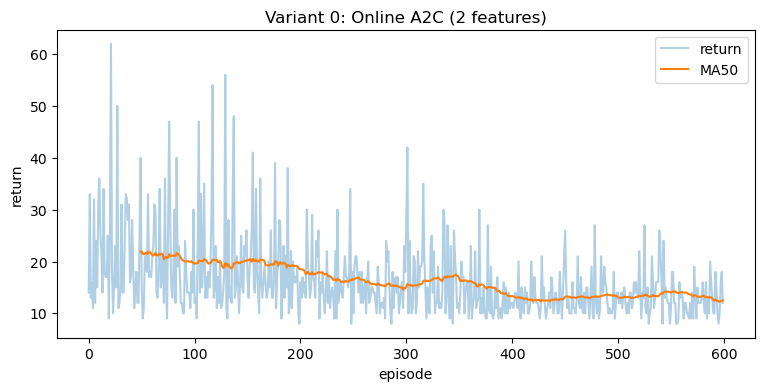

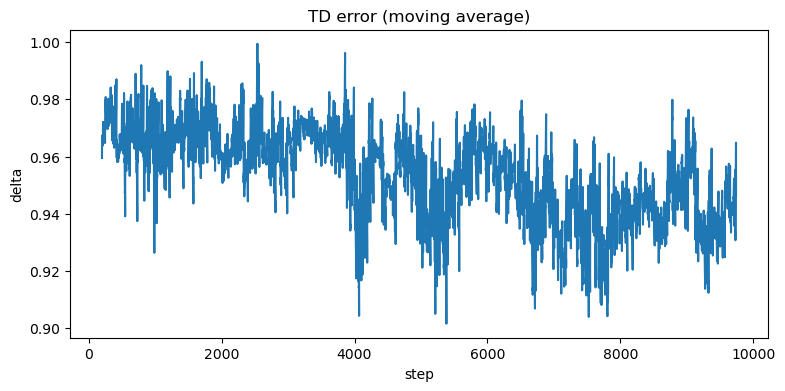

final actor w: [-0.16655993 -1.3944453 ]
final critic v: [0.37153122 1.3759317 ]


In [9]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# ====== utils ======
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def phi(obs):
    # obs = (x, xdot, theta, thetadot)
    x, xdot, th, thdot = obs
    return np.array([th, thdot], dtype=np.float32)

def policy_p(w, features):
    return sigmoid(float(np.dot(w, features)))

def V(v, features):
    return float(np.dot(v, features))

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

# ====== training (online A2C) ======
env = gym.make("CartPole-v1")
rng = np.random.RandomState(0)

episodes = 600
gamma = 0.99

alpha = 0.01
beta  = 0.05

w = np.array([0.0, 0.0], dtype=np.float32)  # actor
v = np.array([0.0, 0.0], dtype=np.float32)  # critic

returns_hist = []
td_hist = []

for ep in range(episodes):
    obs, info = env.reset(seed=ep)
    total = 0.0

    for t in range(500):
        f = phi(obs)

        p = policy_p(w, f)
        a = 1 if rng.rand() < p else 0

        next_obs, r, terminated, truncated, info = env.step(int(a))
        done = terminated or truncated

        f2 = phi(next_obs)

        V_s  = V(v, f)
        V_s2 = V(v, f2)

        delta = float(r) + (0.0 if done else gamma * V_s2) - V_s

        v += beta * delta * f
        w += alpha * (a - p) * f * delta

        obs = next_obs
        total += float(r)
        td_hist.append(delta)

        if done:
            break

    returns_hist.append(total)

    if (ep + 1) % 50 == 0:
        avg = np.mean(returns_hist[-50:])
        print(f"ep {ep+1:4d} | avg_return(last50)={avg:6.1f} | w={w} | v={v}")

env.close()

plt.figure(figsize=(9,4))
plt.plot(returns_hist, alpha=0.35, label="return")
ma = moving_average(returns_hist, 50)
plt.plot(range(49, 49+len(ma)), ma, label="MA50")
plt.title("Variant 0: Online A2C (2 features)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()

plt.figure(figsize=(9,4))
td_ma = moving_average(td_hist, 200)
plt.plot(range(199, 199+len(td_ma)), td_ma)
plt.title("TD error (moving average)")
plt.xlabel("step")
plt.ylabel("delta")
plt.show()

print("final actor w:", w)
print("final critic v:", v)


ep   50 | avg_return(last50)=  18.3 | ||w||=0.40 ||v||=13.50
ep  100 | avg_return(last50)=  19.8 | ||w||=0.48 ||v||=15.93
ep  150 | avg_return(last50)=  22.1 | ||w||=0.74 ||v||=17.04
ep  200 | avg_return(last50)=  16.9 | ||w||=0.91 ||v||=14.41
ep  250 | avg_return(last50)=  14.6 | ||w||=1.33 ||v||=12.27
ep  300 | avg_return(last50)=  15.2 | ||w||=1.61 ||v||=12.36
ep  350 | avg_return(last50)=  15.6 | ||w||=1.42 ||v||=13.50
ep  400 | avg_return(last50)=  14.3 | ||w||=1.19 ||v||=12.69
ep  450 | avg_return(last50)=  14.7 | ||w||=1.88 ||v||=12.84
ep  500 | avg_return(last50)=  13.2 | ||w||=1.63 ||v||=11.83
ep  550 | avg_return(last50)=  14.6 | ||w||=1.50 ||v||=12.85
ep  600 | avg_return(last50)=  13.5 | ||w||=1.31 ||v||=12.19


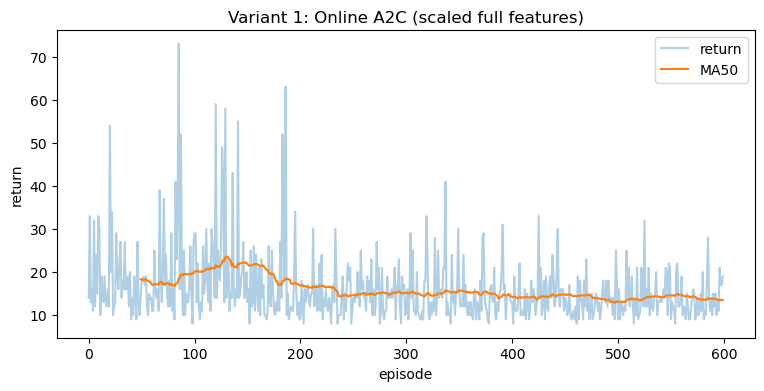

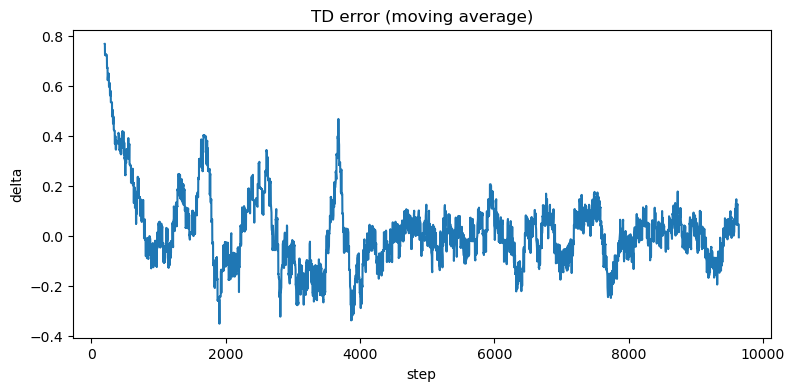

final actor w: [-0.09770259  0.08832303  0.53362924 -0.90704393 -0.77077603]
final critic v: [11.930506   -0.12681712  0.0138835  -2.1037703  -1.3070049 ]


In [10]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def phi(obs):
    x, xdot, th, thdot = obs
    # skalowanie do okolic [-1,1]
    x_s     = x / 2.4
    th_s    = th / 0.209
    xdot_s  = xdot / 2.0
    thdot_s = thdot / 2.0
    # bias + pełniejszy stan
    return np.array([1.0, x_s, xdot_s, th_s, thdot_s], dtype=np.float32)

def policy_p(w, f):
    return sigmoid(float(np.dot(w, f)))

def V(v, f):
    return float(np.dot(v, f))

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

env = gym.make("CartPole-v1")
rng = np.random.RandomState(0)

episodes = 600
gamma = 0.99

alpha = 0.01
beta  = 0.05

d = len(phi(env.reset(seed=0)[0]))
w = np.zeros(d, dtype=np.float32)
v = np.zeros(d, dtype=np.float32)

returns_hist = []
td_hist = []

for ep in range(episodes):
    obs, info = env.reset(seed=ep)
    total = 0.0

    for t in range(500):
        f = phi(obs)
        p = policy_p(w, f)
        a = 1 if rng.rand() < p else 0

        next_obs, r, terminated, truncated, info = env.step(int(a))
        done = terminated or truncated

        f2 = phi(next_obs)

        V_s  = V(v, f)
        V_s2 = V(v, f2)

        delta = float(r) + (0.0 if done else gamma * V_s2) - V_s

        v += beta * delta * f
        w += alpha * (a - p) * f * delta

        obs = next_obs
        total += float(r)
        td_hist.append(delta)

        if done:
            break

    returns_hist.append(total)

    if (ep + 1) % 50 == 0:
        avg = np.mean(returns_hist[-50:])
        print(f"ep {ep+1:4d} | avg_return(last50)={avg:6.1f} | ||w||={np.linalg.norm(w):.2f} ||v||={np.linalg.norm(v):.2f}")

env.close()

plt.figure(figsize=(9,4))
plt.plot(returns_hist, alpha=0.35, label="return")
ma = moving_average(returns_hist, 50)
plt.plot(range(49, 49+len(ma)), ma, label="MA50")
plt.title("Variant 1: Online A2C (scaled full features)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()

plt.figure(figsize=(9,4))
td_ma = moving_average(td_hist, 200)
plt.plot(range(199, 199+len(td_ma)), td_ma)
plt.title("TD error (moving average)")
plt.xlabel("step")
plt.ylabel("delta")
plt.show()

print("final actor w:", w)
print("final critic v:", v)


upd   50 | avg_return(last50)=  20.9 | ||w||=0.04 ||v||=11.30
upd  100 | avg_return(last50)=  24.2 | ||w||=0.10 ||v||=11.23
upd  150 | avg_return(last50)=  24.9 | ||w||=0.16 ||v||=12.37
upd  200 | avg_return(last50)=  24.5 | ||w||=0.21 ||v||=12.48
upd  250 | avg_return(last50)=  22.9 | ||w||=0.31 ||v||=12.07
upd  300 | avg_return(last50)=  26.6 | ||w||=0.37 ||v||=12.23
upd  350 | avg_return(last50)=  27.8 | ||w||=0.44 ||v||=13.93
upd  400 | avg_return(last50)=  25.6 | ||w||=0.50 ||v||=12.94
upd  450 | avg_return(last50)=  29.1 | ||w||=0.57 ||v||=13.34
upd  500 | avg_return(last50)=  30.0 | ||w||=0.69 ||v||=15.41
upd  550 | avg_return(last50)=  31.4 | ||w||=0.78 ||v||=14.48
upd  600 | avg_return(last50)=  36.7 | ||w||=0.90 ||v||=18.25
upd  650 | avg_return(last50)=  44.2 | ||w||=0.99 ||v||=18.55
upd  700 | avg_return(last50)=  48.5 | ||w||=1.09 ||v||=18.98
upd  750 | avg_return(last50)=  50.8 | ||w||=1.18 ||v||=21.73
upd  800 | avg_return(last50)=  39.6 | ||w||=1.29 ||v||=18.72
upd  850

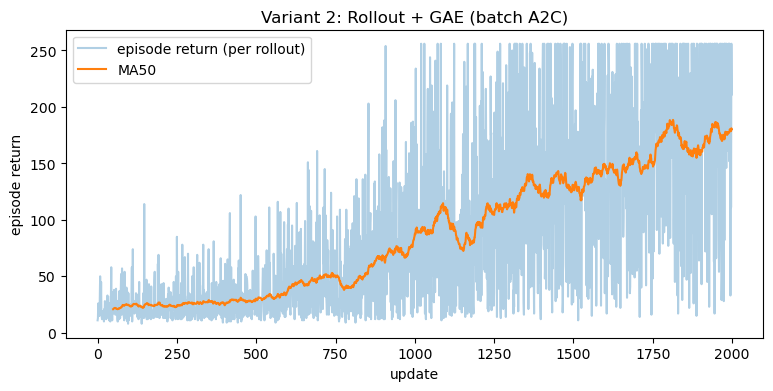

final actor w: [-0.0028941   0.09401915 -0.71852002  2.28784252  1.67299207]
final critic v: [59.415325   -0.98655933 -2.184518    0.15340333 -0.6378144 ]


In [11]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def phi(obs):
    x, xdot, th, thdot = obs
    x_s     = x / 2.4
    th_s    = th / 0.209
    xdot_s  = xdot / 2.0
    thdot_s = thdot / 2.0
    return np.array([1.0, x_s, xdot_s, th_s, thdot_s], dtype=np.float32)

def pi_prob(w, f):
    return sigmoid(float(np.dot(w, f)))

def V(v, f):
    return float(np.dot(v, f))

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

def collect_rollout(env, w, v, T, gamma, rng):
    obs, info = env.reset()
    f_list, a_list, r_list, done_list, V_list, p_list = [], [], [], [], [], []
    ep_return = 0.0

    for _ in range(T):
        f = phi(obs)
        p = pi_prob(w, f)
        a = 1 if rng.rand() < p else 0

        V_s = V(v, f)
        next_obs, r, terminated, truncated, info = env.step(int(a))
        done = terminated or truncated

        f_list.append(f)
        a_list.append(a)
        r_list.append(float(r))
        done_list.append(done)
        V_list.append(V_s)
        p_list.append(p)

        ep_return += float(r)
        obs = next_obs
        if done:
            break

    V_last = 0.0 if done_list[-1] else V(v, phi(obs))

    return (np.stack(f_list),
            np.array(a_list),
            np.array(r_list, dtype=np.float32),
            np.array(done_list),
            np.array(V_list, dtype=np.float32),
            np.array(p_list, dtype=np.float32),
            float(V_last),
            float(ep_return))

def compute_gae(r, done, V_t, V_last, gamma=0.99, lam=0.95):
    T = len(r)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        V_next = V_last if t == T-1 else V_t[t+1]
        nonterminal = 0.0 if done[t] else 1.0
        delta = r[t] + gamma * V_next * nonterminal - V_t[t]
        gae = delta + gamma * lam * nonterminal * gae
        adv[t] = gae
    ret = adv + V_t
    return adv, ret

def clip_norm(vec, max_norm):
    n = float(np.linalg.norm(vec))
    if n <= max_norm:
        return vec
    return vec * (max_norm / (n + 1e-8))

env = gym.make("CartPole-v1")
rng = np.random.RandomState(0)

updates = 2000     # liczba update'ów (rolloutów)
T = 256            # rollout length
gamma = 0.99
lam = 0.95

alpha = 0.05       # actor lr
beta  = 0.1        # critic lr
clip_w = 1.0
clip_v = 2.0

d = len(phi(env.reset(seed=0)[0]))
w = np.zeros(d, dtype=np.float32)
v = np.zeros(d, dtype=np.float32)

returns_hist = []

for k in range(updates):
    f, a, r, done, V_t, p, V_last, ep_ret = collect_rollout(env, w, v, T, gamma, rng)
    adv, ret = compute_gae(r, done, V_t, V_last, gamma=gamma, lam=lam)

    # normalizacja advantage
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    # critic update (MSE)
    td = (ret - V_t)
    grad_v = (td[:, None] * f).mean(axis=0)
    step_v = clip_norm(beta * grad_v, clip_v)
    v = v + step_v

    # actor update (policy gradient)
    grad_logp = ((a - p)[:, None] * f)  # per-sample
    grad_w = (grad_logp * adv[:, None]).mean(axis=0)
    step_w = clip_norm(alpha * grad_w, clip_w)
    w = w + step_w

    returns_hist.append(ep_ret)

    if (k + 1) % 50 == 0:
        avg50 = np.mean(returns_hist[-50:])
        print(f"upd {k+1:4d} | avg_return(last50)={avg50:6.1f} | ||w||={np.linalg.norm(w):.2f} ||v||={np.linalg.norm(v):.2f}")

env.close()

plt.figure(figsize=(9,4))
plt.plot(returns_hist, alpha=0.35, label="episode return (per rollout)")
ma = moving_average(returns_hist, 50)
plt.plot(range(49, 49+len(ma)), ma, label="MA50")
plt.title("Variant 2: Rollout + GAE (batch A2C)")
plt.xlabel("update")
plt.ylabel("episode return")
plt.legend()
plt.show()

print("final actor w:", w)
print("final critic v:", v)


## Interpretacja wyników: Variant 0 vs 1 vs 2 (dokładnie)

Poniżej podsumowujemy trzy warianty A2C (bez sieci) i co z nich wynika.

---

### Variant 0 — Online A2C (2 features)

**Co widać na wykresie:**
- MA50 spada (z ~22 w okolice ~13)
- brak trwałego trendu wzrostowego
- duży szum, ale średnia nie rośnie

**Interpretacja:**
- Actor dostaje sygnał oparty o bardzo lokalny TD-error oraz bardzo ubogą reprezentację stanu $\phi(s)=[\theta,\dot\theta]$.
- Update wykonywany co krok (online) ma dużą wariancję.
- Efekt: polityka nie uczy się stabilnie, często wręcz degeneruje.

**Wniosek dydaktyczny:**
- Sam “mechanizm A2C” nie wystarczy — reprezentacja i stabilizacja estymatora gradientu są krytyczne.

---

### Variant 1 — Online A2C (scaled full features)

**Co widać:**
- lekka poprawa w porównaniu do wariantu 0 (czasem MA50 trochę lepsze),
- ale nadal brak wyraźnego, trwałego trendu wzrostowego.

**Co się zmieniło:**
- poprawiliśmy $\phi(s)$: dodaliśmy bias i komponenty wózka oraz skalowanie.

**Interpretacja:**
- Lepsza reprezentacja pomaga (sygnał dla aktora ma sensowniejszą strukturę),
- ale update online TD(0) nadal jest bardzo szumiący → brak stabilnego wzrostu jakości polityki.

**Wniosek dydaktyczny:**
- Dobre cechy i skala są często warunkiem koniecznym, ale nie zawsze wystarczają.
- Potrzebujemy lepszego “estymatora advantage” i/lub batchowego uczenia.

---

### Variant 2 — Rollout + GAE (batch A2C)

**Co widać:**
- MA50 rośnie systematycznie i wyraźnie (silny trend uczenia),
- dużo szumu w pojedynczych epizodach, ale średnia rośnie.

**Co się zmieniło (kluczowe):**
1) Zbieramy rollout długości $T$ i aktualizujemy batchowo (a nie co krok).  
2) Advantage liczymy przez GAE zamiast TD(0).  
3) Normalizujemy advantage (stabilizacja).

**Interpretacja:**
- To daje znacznie lepszy i mniej szumiący sygnał dla aktora.
- Uczenie rusza nawet dla liniowej polityki bez sieci.

**Wniosek dydaktyczny (najważniejszy):**
- Ogromna różnica nie wynika z “większego modelu”, tylko z jakości estymacji gradientu.
- Variant 2 to praktycznie “minimum”, na którym sensownie buduje się PPO.

---

## Najważniejsze wnioski porównawcze

1) **Reprezentacja i skala** (Variant 1) pomagają, ale nie gwarantują sukcesu.  
2) **Online TD(0)** bywa zbyt szumiące dla policy gradient.  
3) **Batch + GAE + normalizacja advantage** (Variant 2) to realna stabilizacja i widoczny postęp.


# PPO

---

# Przechodzimy do PPO — ale najpierw wprowadzenie

PPO (Proximal Policy Optimization) to metoda policy-gradient, która:
- pozwala robić kilka aktualizacji na tym samym batchu danych,
- ale ogranicza “za duży krok” polityki (żeby nie rozjechać uczenia).

Żeby to dobrze zrozumieć, musimy mieć jasność co to jest:
1) Advantage $A_t$  
2) GAE (Generalized Advantage Estimation)  
3) ratio $r_t$ (nowa polityka / stara polityka)  
4) clipped objective PPO  
5) rola critika $V(s)$ w PPO



# Wprowadzenie do PPO od podstaw

## 1) Dlaczego nie wystarczy REINFORCE / “goły” policy gradient?

REINFORCE używa Monte Carlo:
$$
\nabla_\theta J(\theta)=\mathbb{E}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t)\,G_t\right]
$$

Problem: $G_t$ ma dużą wariancję → uczenie bywa niestabilne.

A2C poprawia to przez critic:
- uczy $V(s)$,
- używa advantage zamiast $G_t$.

---

## 2) Co to jest advantage?

Advantage mówi:
> “czy dana akcja była lepsza niż to, czego się spodziewaliśmy w tym stanie?”

Formalnie:
$$
A^\pi(s_t,a_t)=Q^\pi(s_t,a_t)-V^\pi(s_t)
$$

W praktyce nie znamy $Q$ dokładnie, więc używamy przybliżeń.

Najprostsze przybliżenie (TD(0)), znamy już z poprzednich zajęć:
$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$
i traktujemy $\delta_t$ jako advantage.

Ale TD(0) bywa bardzo szumiące.

---

## 3) Co to jest GAE (Generalized Advantage Estimation)?

GAE to sposób liczenia advantage, który balansuje:
- niską wariancję (jak TD),
- mały bias (jak Monte Carlo).

Zaczynamy od TD-error:
$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

GAE liczy advantage jako wygładzoną sumę przyszłych TD-error:
$$
A_t^{\text{GAE}(\gamma,\lambda)} = \sum_{k=0}^{\infty} (\gamma\lambda)^k\,\delta_{t+k}
$$

Parametr $\lambda \in [0,1]$:
- $\lambda \to 0$ → bardzo lokalne TD (mała wariancja, większy bias),
- $\lambda \to 1$ → bardziej Monte Carlo (mniejszy bias, większa wariancja).

W praktyce często $\lambda \approx 0.95$.

**Intuicja:**  
GAE mówi: “nie ufaj tylko jednemu TD-error, uśrednij informację z kilku kroków”.

---

## 4) Dlaczego PPO?

Nawet z GAE nadal mamy problem:
- policy gradient może wykonać zbyt duży krok,
- a to może drastycznie pogorszyć politykę (katastrofa).

PPO wprowadza mechanizm:
> “Ucz się na batchu kilka razy, ale nie pozwól polityce zmienić się za bardzo”.

---

## 5) ratio $r_t$ (najważniejszy element PPO)

Mamy:
- starą politykę $\pi_{\text{old}}$ (która zebrała dane),
- nową politykę $\pi_\theta$ (którą aktualizujemy).

Definiujemy:
$$
r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\text{old}}(a_t|s_t)}
$$

Interpretacja:
- $r_t > 1$ → nowa polityka zwiększyła prawdopodobieństwo tej akcji,
- $r_t < 1$ → zmniejszyła.

---

## 6) clipped objective PPO

Zwykły policy gradient maksymalizowałby:
$$
\mathbb{E}[r_t(\theta) A_t]
$$

PPO mówi: jeśli $r_t$ robi się “za duże” lub “za małe”, to klipujemy:

$$
L^{\text{CLIP}}(\theta)=
\mathbb{E}\left[
\min\left(
r_t(\theta)A_t,
\text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\,A_t
\right)
\right]
$$

Gdzie $\epsilon$ to mały parametr, np. 0.2.

**Interpretacja:**
- jeśli nowa polityka próbuje zbyt mocno zmienić prawdopodobieństwa → PPO hamuje update.

---

## 7) Co zostaje z A2C, a co dochodzi w PPO?

Z A2C zostaje:
- critic $V(s)$,
- advantage (najlepiej GAE),
- batch rollout.

Dochodzi:
- przechowywanie “starej” polityki (wagi $w_{\text{old}}$),
- ratio $r_t$,
- clipped objective,
- kilka epok aktualizacji na tym samym batchu (minibatch SGD).


## Notatka dotycząca podobieństw z TD($\lambda$)

## Czym różni się GAE od TD($\lambda$)?

### 1) Co estymuje TD($\lambda$)?
TD($\lambda$) to metoda do uczenia funkcji wartości, najczęściej $V(s)$.

Jej cel to przybliżyć $V^\pi(s)$ przez tzw. **$\lambda$-return**:

$$
G_t^{(\lambda)} = (1-\lambda)\sum_{n=1}^{\infty}\lambda^{n-1} G_t^{(n)}
$$

gdzie $G_t^{(n)}$ to n-step return:

$$
G_t^{(n)} = \sum_{k=0}^{n-1}\gamma^k r_{t+k} + \gamma^n V(s_{t+n})
$$

Następnie TD($\lambda$) aktualizuje parametry $V$ tak, aby:

$$
V(s_t) \approx G_t^{(\lambda)}
$$

(albo równoważnie robi update przez **eligibility traces**).

**W skrócie:** TD($\lambda$) miesza informacje z wielu horyzontów, żeby lepiej uczyć $V$.

---

### 2) Co estymuje GAE?
GAE (Generalized Advantage Estimation) estymuje **advantage**:

$$
A^\pi(s_t,a_t) = Q^\pi(s_t,a_t) - V^\pi(s_t)
$$

czyli sygnał “czy ta akcja była lepsza niż oczekiwano w tym stanie”.

GAE buduje advantage z TD-error:

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

i robi wygładzoną sumę:

$$
A_t^{\text{GAE}(\gamma,\lambda)} = \sum_{k=0}^{\infty}(\gamma\lambda)^k \delta_{t+k}
$$

**W skrócie:** GAE miesza TD-error z wielu kroków, żeby dać stabilniejszy sygnał dla aktora.

---

### 3) Najważniejsza relacja: GAE to “TD($\lambda$) minus wartość stanu”
Istnieje bardzo ważna tożsamość:

$$
A_t^{\text{GAE}(\gamma,\lambda)} = G_t^{(\lambda)} - V(s_t)
$$

Czyli:
- TD($\lambda$) daje “lepszy” target dla wartości $V$,
- a GAE bierze ten target i odejmuje $V(s_t)$, tworząc advantage.

---

### 4) Praktyczna różnica w użyciu (dydaktycznie)

- **TD($\lambda$)**: używasz głównie do uczenia *critika* (wartości stanu).
- **GAE**: używasz głównie do uczenia *actora* (polityki), bo actor potrzebuje advantage.

Obie metody kontrolują trade-off bias/variance parametrem $\lambda$:
- $\lambda \to 0$ → bardziej TD(0): mniejsza wariancja, większy bias
- $\lambda \to 1$ → bardziej Monte Carlo: mniejszy bias, większa wariancja

---

### 5) Intuicja w jednym zdaniu
- TD($\lambda$) mówi: “jak najlepiej przewidzieć przyszłą sumę nagród?”  
- GAE mówi: “czy ta akcja była lepsza niż moja bieżąca predykcja wartości?”


# PPO (bez sieci): linear actor + linear critic (CartPole)

## Co dokładamy względem A2C (Variant 2)?
A2C (rollout+GAE) robi jeden update na batchu.

PPO robi to samo, ale:
1) zapamiętuje starą politykę $\pi_{\text{old}}$ (czyli log-prob z rolloutów),
2) robi kilka epok aktualizacji na tym samym batchu,
3) hamuje zbyt duże zmiany przez clipped objective.

Kluczowe pojęcia:

- ratio:
$$
r_t=\frac{\pi_\theta(a_t|s_t)}{\pi_{\text{old}}(a_t|s_t)}
$$

- clipped objective:
$$
\min(r_t A_t,\ \text{clip}(r_t,1-\epsilon,1+\epsilon)A_t)
$$


upd   50 | avg_return(last50)=  24.3 | ||w||=0.54 ||v||=12.62
upd  100 | avg_return(last50)=  35.1 | ||w||=1.06 ||v||=25.44
upd  150 | avg_return(last50)=  58.8 | ||w||=1.59 ||v||=20.46
upd  200 | avg_return(last50)=  93.8 | ||w||=2.12 ||v||=42.58
upd  250 | avg_return(last50)= 150.0 | ||w||=2.52 ||v||=51.18
upd  300 | avg_return(last50)= 163.2 | ||w||=2.92 ||v||=65.38
upd  350 | avg_return(last50)= 219.6 | ||w||=3.16 ||v||=70.15
upd  400 | avg_return(last50)= 216.3 | ||w||=3.32 ||v||=65.24
upd  450 | avg_return(last50)= 238.1 | ||w||=3.62 ||v||=78.39
upd  500 | avg_return(last50)= 250.2 | ||w||=3.75 ||v||=79.23
upd  550 | avg_return(last50)= 286.7 | ||w||=3.76 ||v||=82.91
upd  600 | avg_return(last50)= 289.9 | ||w||=3.81 ||v||=73.36
upd  650 | avg_return(last50)= 260.4 | ||w||=3.91 ||v||=70.75
upd  700 | avg_return(last50)= 221.8 | ||w||=4.04 ||v||=72.55
upd  750 | avg_return(last50)= 218.4 | ||w||=4.09 ||v||=91.20
upd  800 | avg_return(last50)= 260.6 | ||w||=4.18 ||v||=79.06
upd  850

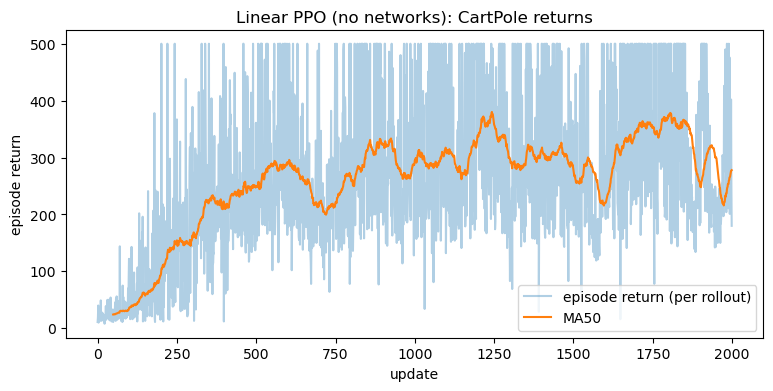

final actor w: [-0.2325649   0.18785313 -0.500647    3.6338975   3.221279  ]
final critic v: [ 7.7730705e+01 -2.6575981e+01 -3.2843812e+00 -3.1342171e-02
  8.9143839e+00]


In [13]:

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Features (scaled)
# -----------------------
def phi(obs):
    x, xdot, th, thdot = obs
    x_s     = x / 2.4
    th_s    = th / 0.209
    xdot_s  = xdot / 2.0
    thdot_s = thdot / 2.0
    return np.array([1.0, x_s, xdot_s, th_s, thdot_s], dtype=np.float32)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# policy prob and logprob for Bernoulli(sigmoid)
def pi_prob(w, f):
    return sigmoid(float(np.dot(w, f)))

def logprob_bernoulli(p, a):
    # a in {0,1}
    if a == 1:
        return np.log(p + 1e-8)
    else:
        return np.log(1.0 - p + 1e-8)

def entropy_bernoulli(p):
    return -(p * np.log(p + 1e-8) + (1 - p) * np.log(1 - p + 1e-8))

def V(v, f):
    return float(np.dot(v, f))

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

def clip_norm(vec, max_norm):
    n = float(np.linalg.norm(vec))
    if n <= max_norm:
        return vec
    return vec * (max_norm / (n + 1e-8))

# -----------------------
# Rollout collection
# -----------------------
def collect_rollout(env, w, v, T, gamma, rng):
    obs, info = env.reset()
    f_list, a_list, r_list, done_list = [], [], [], []
    V_list, logp_old_list, ent_list = [], [], []
    ep_return = 0.0

    for _ in range(T):
        f = phi(obs)
        p = pi_prob(w, f)
        a = 1 if rng.rand() < p else 0

        logp = logprob_bernoulli(p, a)
        ent  = entropy_bernoulli(p)

        V_s = V(v, f)

        next_obs, r, terminated, truncated, info = env.step(int(a))
        done = terminated or truncated

        f_list.append(f)
        a_list.append(a)
        r_list.append(float(r))
        done_list.append(done)
        V_list.append(V_s)
        logp_old_list.append(logp)
        ent_list.append(ent)

        ep_return += float(r)
        obs = next_obs
        if done:
            break

    V_last = 0.0 if done_list[-1] else V(v, phi(obs))

    return (np.stack(f_list),
            np.array(a_list, dtype=np.int32),
            np.array(r_list, dtype=np.float32),
            np.array(done_list, dtype=bool),
            np.array(V_list, dtype=np.float32),
            float(V_last),
            np.array(logp_old_list, dtype=np.float32),
            np.array(ent_list, dtype=np.float32),
            float(ep_return))

# -----------------------
# GAE(lambda)
# -----------------------
def compute_gae(r, done, V_t, V_last, gamma=0.99, lam=0.95):
    T = len(r)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        V_next = V_last if t == T-1 else V_t[t+1]
        nonterminal = 0.0 if done[t] else 1.0
        delta = r[t] + gamma * V_next * nonterminal - V_t[t]
        gae = delta + gamma * lam * nonterminal * gae
        adv[t] = gae
    ret = adv + V_t
    return adv, ret

# -----------------------
# PPO Train (linear)
# -----------------------
env = gym.make("CartPole-v1")
rng = np.random.RandomState(0)

updates = 2000     # liczba rolloutów (aktualizacji)
T = 512            # długość rolloutów
gamma = 0.99
lam = 0.95

# PPO hyperparams
clip_eps = 0.2
ppo_epochs = 5
minibatch_size = 128

alpha = 0.05       # actor lr
beta  = 0.1        # critic lr
ent_coef = 0.01    # bonus entropii (zachęca do eksploracji)
clip_w = 1.0
clip_v = 2.0

d = len(phi(env.reset(seed=0)[0]))
w = np.zeros(d, dtype=np.float32)
v = np.zeros(d, dtype=np.float32)

returns_hist = []

for k in range(updates):
    f, a, r, done, V_t, V_last, logp_old, ent_old, ep_ret = collect_rollout(env, w, v, T, gamma, rng)

    adv, ret = compute_gae(r, done, V_t, V_last, gamma=gamma, lam=lam)
    # normalizacja advantage
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    N = len(r)
    idx = np.arange(N)

    # kilka epok PPO na tym samym batchu
    for _ in range(ppo_epochs):
        rng.shuffle(idx)

        for start in range(0, N, minibatch_size):
            mb = idx[start:start+minibatch_size]

            f_mb = f[mb]
            a_mb = a[mb]
            adv_mb = adv[mb]
            ret_mb = ret[mb]
            logp_old_mb = logp_old[mb]

            # --- compute new logp under current w ---
            # p = sigmoid(f @ w)
            z = f_mb @ w
            p = 1.0 / (1.0 + np.exp(-z))
            logp = np.where(a_mb == 1, np.log(p + 1e-8), np.log(1 - p + 1e-8))

            # ratio
            ratio = np.exp(logp - logp_old_mb)

            # clipped surrogate
            unclipped = ratio * adv_mb
            clipped = np.clip(ratio, 1 - clip_eps, 1 + clip_eps) * adv_mb
            # PPO objective: maximize min(...)
            # we'll compute gradient manually for linear Bernoulli:
            # grad logp = (a - p) * f
            # For PPO, gradient uses coeff depending on whether clipped is active.
            use_unclipped = (unclipped <= clipped).astype(np.float32)  # if min chooses unclipped
            coeff = use_unclipped * ratio + (1 - use_unclipped) * np.clip(ratio, 1 - clip_eps, 1 + clip_eps)
            # objective contribution ~ coeff * adv
            # gradient of objective wrt w: coeff*adv * grad(logp)
            grad_logp = ((a_mb - p).astype(np.float32)[:, None] * f_mb)
            grad_w = (coeff * adv_mb).astype(np.float32)[:, None] * grad_logp
            grad_w = grad_w.mean(axis=0)

            # entropy bonus gradient (pomijamy analitycznie, dodamy mały push jak wcześniej)
            grad_entropy_push = -0.001 * np.sign(w)

            step_w = alpha * grad_w + ent_coef * grad_entropy_push
            step_w = clip_norm(step_w, clip_w)
            w = w + step_w

            # --- critic update (MSE to ret) ---
            V_pred = f_mb @ v
            td = (ret_mb - V_pred).astype(np.float32)
            grad_v = (td[:, None] * f_mb).mean(axis=0)
            step_v = beta * grad_v
            step_v = clip_norm(step_v, clip_v)
            v = v + step_v

    returns_hist.append(ep_ret)

    if (k + 1) % 50 == 0:
        avg50 = np.mean(returns_hist[-50:])
        print(f"upd {k+1:4d} | avg_return(last50)={avg50:6.1f} | ||w||={np.linalg.norm(w):.2f} ||v||={np.linalg.norm(v):.2f}")

env.close()

plt.figure(figsize=(9,4))
plt.plot(returns_hist, alpha=0.35, label="episode return (per rollout)")
ma = moving_average(returns_hist, 50)
plt.plot(range(49, 49+len(ma)), ma, label="MA50")
plt.title("Linear PPO (no networks): CartPole returns")
plt.xlabel("update")
plt.ylabel("episode return")
plt.legend()
plt.show()

print("final actor w:", w)
print("final critic v:", v)


# PPO (bez sieci) – krótkie podsumowanie

## Co to jest PPO?
PPO (Proximal Policy Optimization) to metoda policy gradient, która:
1) zbiera rollouty z “starej” polityki $\pi_{\text{old}}$,
2) liczy advantage $A_t$ (najczęściej przez GAE),
3) robi kilka epok update na tym samym batchu,
4) ale ogranicza zbyt duże zmiany polityki przez **clipping**.

## Kluczowe elementy PPO

### (A) Ratio
$$
r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\text{old}}(a_t|s_t)}
$$

### (B) Clipped objective
$$
L^{\text{CLIP}}(\theta)=
\mathbb{E}\left[
\min\left(
r_t(\theta)A_t,\ 
\text{clip}(r_t(\theta),1-\epsilon,1+\epsilon)A_t
\right)
\right]
$$

### (C) Critic i GAE
Critic uczy $V(s)$, a advantage liczymy:
$$
A_t^{\text{GAE}} = \sum_{k\ge 0}(\gamma\lambda)^k\,\delta_{t+k},\quad
\delta_t=r_t+\gamma V(s_{t+1})-V(s_t)
$$

## Co pokazały wyniki PPO u nas?
- szybkie dojście do wysokich returnów,
- możliwość dalszego “dopychania” wyniku wieloma epokami na batchu,
- mniejsze ryzyko katastrofalnych kroków (clip).
Wahania nadal występują, bo polityka jest stochastyczna, a critic bywa źródłem szumu.


# Ćwiczenie 2: Wpływ parametru clip $\epsilon$ w PPO

## Cel

Zobaczyć kompromis (trade-off) między szybkością uczenia a stabilnością polityki:

- małe $\epsilon$ → stabilniej, ale wolniej,
- duże $\epsilon$ → szybciej, ale większe wahania.

---

## Zadanie

Uruchom PPO dla trzech wartości parametru clip:

- `clip_eps = 0.1`
- `clip_eps = 0.2`
- `clip_eps = 0.3`

Dla każdej konfiguracji:

1. Zapisz wartość `MA50` po:
   - 500 update’ach,
   - 1000 update’ach.
2. Zwróć uwagę na:
   - liczbę wyraźnych „dołków” (nagłych spadków MA50),
   - stabilność krzywej uczenia,
   - wahania w ewaluacji deterministycznej.

---

## Rozwiązanie

W kodzie PPO zmieniasz tylko jedną linię:

```python
clip_eps = 0.1   # albo 0.2, albo 0.3


I sprawdzasz/analizujesz :)

In [14]:
def run_episode_deterministic(env, w, seed=0, max_steps=500):
    obs, info = env.reset(seed=seed)
    total = 0.0
    for _ in range(max_steps):
        f = phi(obs)
        p = pi_prob(w, f)
        a = 1 if p > 0.5 else 0
        obs, r, terminated, truncated, info = env.step(int(a))
        total += float(r)
        if terminated or truncated:
            break
    return total

def evaluate_deterministic(w, episodes=20, seed=123):
    env_eval = gym.make("CartPole-v1")
    rets = []
    for i in range(episodes):
        rets.append(run_episode_deterministic(env_eval, w, seed=seed+i))
    env_eval.close()
    return float(np.mean(rets)), float(np.std(rets))


upd   50 | train_avg50=  24.4 | eval_det= 220.9± 13.0 | ||w||=0.59
upd  100 | train_avg50=  35.8 | eval_det= 462.6± 42.9 | ||w||=0.93
upd  150 | train_avg50=  42.6 | eval_det= 280.7± 26.6 | ||w||=1.26
upd  200 | train_avg50=  66.1 | eval_det= 394.5± 67.8 | ||w||=1.76
upd  250 | train_avg50= 105.7 | eval_det= 288.6± 21.4 | ||w||=2.09
upd  300 | train_avg50= 123.9 | eval_det= 457.9± 52.0 | ||w||=2.45
upd  350 | train_avg50= 187.4 | eval_det= 488.3± 34.5 | ||w||=2.92
upd  400 | train_avg50= 261.1 | eval_det= 500.0±  0.0 | ||w||=3.12
upd  450 | train_avg50= 274.8 | eval_det= 491.5± 37.1 | ||w||=3.34
upd  500 | train_avg50= 271.3 | eval_det= 491.4± 37.3 | ||w||=3.54
upd  550 | train_avg50= 216.6 | eval_det= 500.0±  0.0 | ||w||=3.67
upd  600 | train_avg50= 275.9 | eval_det= 500.0±  0.0 | ||w||=3.77
upd  650 | train_avg50= 278.7 | eval_det= 264.8± 20.0 | ||w||=3.84
upd  700 | train_avg50= 276.7 | eval_det= 491.4± 37.7 | ||w||=3.85
upd  750 | train_avg50= 247.2 | eval_det= 350.7± 68.0 | ||w||=

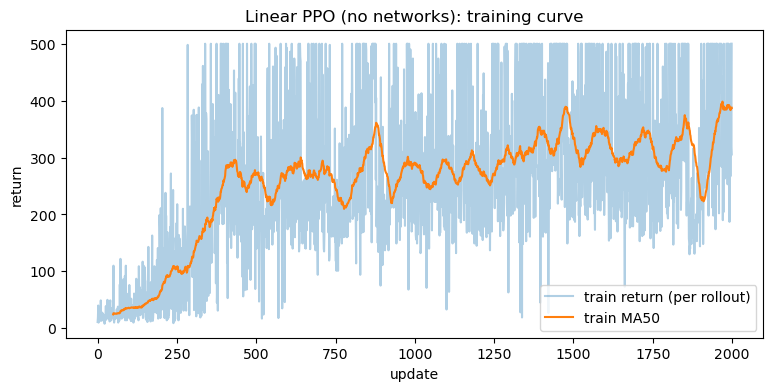

final actor w: [-0.15872313  0.44659477 -0.80802625  3.5782676   3.02392   ]
final critic v: [ 81.215454  -18.763325  -17.999191    1.9982525  -3.7894092]


In [17]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Features (scaled)
# -----------------------
def phi(obs):
    x, xdot, th, thdot = obs
    x_s     = x / 2.4
    th_s    = th / 0.209
    xdot_s  = xdot / 2.0
    thdot_s = thdot / 2.0
    return np.array([1.0, x_s, xdot_s, th_s, thdot_s], dtype=np.float32)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def pi_prob(w, f):
    return sigmoid(float(np.dot(w, f)))

def logprob_bernoulli(p, a):
    return np.log(p + 1e-8) if a == 1 else np.log(1.0 - p + 1e-8)

def V(v, f):
    return float(np.dot(v, f))

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

def clip_norm(vec, max_norm):
    n = float(np.linalg.norm(vec))
    if n <= max_norm:
        return vec
    return vec * (max_norm / (n + 1e-8))

# -----------------------
# Rollout collection
# -----------------------
def collect_rollout(env, w, v, T, rng):
    obs, info = env.reset()
    f_list, a_list, r_list, done_list = [], [], [], []
    V_list, logp_old_list = [], []
    ep_return = 0.0

    for _ in range(T):
        f = phi(obs)
        p = pi_prob(w, f)
        a = 1 if rng.rand() < p else 0

        logp = logprob_bernoulli(p, a)
        V_s = V(v, f)

        next_obs, r, terminated, truncated, info = env.step(int(a))
        done = terminated or truncated

        f_list.append(f)
        a_list.append(a)
        r_list.append(float(r))
        done_list.append(done)
        V_list.append(V_s)
        logp_old_list.append(logp)

        ep_return += float(r)
        obs = next_obs
        if done:
            break

    V_last = 0.0 if done_list[-1] else V(v, phi(obs))

    return (np.stack(f_list),
            np.array(a_list, dtype=np.int32),
            np.array(r_list, dtype=np.float32),
            np.array(done_list, dtype=bool),
            np.array(V_list, dtype=np.float32),
            float(V_last),
            np.array(logp_old_list, dtype=np.float32),
            float(ep_return))

# -----------------------
# GAE(lambda)
# -----------------------
def compute_gae(r, done, V_t, V_last, gamma=0.99, lam=0.95):
    T = len(r)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        V_next = V_last if t == T-1 else V_t[t+1]
        nonterminal = 0.0 if done[t] else 1.0
        delta = r[t] + gamma * V_next * nonterminal - V_t[t]
        gae = delta + gamma * lam * nonterminal * gae
        adv[t] = gae
    ret = adv + V_t
    return adv, ret

# -----------------------
# Deterministic evaluation
# -----------------------
def run_episode_deterministic(env, w, seed=0, max_steps=500):
    obs, info = env.reset(seed=seed)
    total = 0.0
    for _ in range(max_steps):
        f = phi(obs)
        p = pi_prob(w, f)
        a = 1 if p > 0.5 else 0
        obs, r, terminated, truncated, info = env.step(int(a))
        total += float(r)
        if terminated or truncated:
            break
    return total

def evaluate_deterministic(w, episodes=20, seed=123):
    env_eval = gym.make("CartPole-v1")
    rets = [run_episode_deterministic(env_eval, w, seed=seed+i) for i in range(episodes)]
    env_eval.close()
    return float(np.mean(rets)), float(np.std(rets))

# -----------------------
# PPO Train (linear)
# -----------------------
env = gym.make("CartPole-v1")
rng = np.random.RandomState(0)

updates = 2000
T = 512
gamma = 0.99
lam = 0.95

clip_eps = 0.2
ppo_epochs = 5
minibatch_size = 128

alpha = 0.05
beta  = 0.1
clip_w = 1.0
clip_v = 2.0

d = len(phi(env.reset(seed=0)[0]))
w = np.zeros(d, dtype=np.float32)
v = np.zeros(d, dtype=np.float32)

train_returns = []
eval_means = []

for k in range(updates):
    f, a, r, done, V_t, V_last, logp_old, ep_ret = collect_rollout(env, w, v, T, rng)
    adv, ret = compute_gae(r, done, V_t, V_last, gamma=gamma, lam=lam)
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    N = len(r)
    idx = np.arange(N)

    for _ in range(ppo_epochs):
        rng.shuffle(idx)
        for start in range(0, N, minibatch_size):
            mb = idx[start:start+minibatch_size]

            f_mb = f[mb]
            a_mb = a[mb]
            adv_mb = adv[mb]
            ret_mb = ret[mb]
            logp_old_mb = logp_old[mb]

            z = f_mb @ w
            p = 1.0 / (1.0 + np.exp(-z))
            logp = np.where(a_mb == 1, np.log(p + 1e-8), np.log(1 - p + 1e-8))

            ratio = np.exp(logp - logp_old_mb)

            unclipped = ratio * adv_mb
            clipped = np.clip(ratio, 1 - clip_eps, 1 + clip_eps) * adv_mb

            # min() wybiera elementowo mniejsze z dwóch
            use_unclipped = (unclipped <= clipped).astype(np.float32)
            chosen_ratio = use_unclipped * ratio + (1 - use_unclipped) * np.clip(ratio, 1 - clip_eps, 1 + clip_eps)

            grad_logp = ((a_mb - p).astype(np.float32)[:, None] * f_mb)
            grad_w = ((chosen_ratio * adv_mb).astype(np.float32)[:, None] * grad_logp).mean(axis=0)

            step_w = clip_norm(alpha * grad_w, clip_w)
            w = w + step_w

            V_pred = f_mb @ v
            td = (ret_mb - V_pred).astype(np.float32)
            grad_v = (td[:, None] * f_mb).mean(axis=0)
            step_v = clip_norm(beta * grad_v, clip_v)
            v = v + step_v

    train_returns.append(ep_ret)

    if (k + 1) % 50 == 0:
        avg50 = np.mean(train_returns[-50:])
        eval_mean, eval_std = evaluate_deterministic(w, episodes=20, seed=1000+k)
        eval_means.append(eval_mean)
        print(f"upd {k+1:4d} | train_avg50={avg50:6.1f} | eval_det={eval_mean:6.1f}±{eval_std:5.1f} | ||w||={np.linalg.norm(w):.2f}")

env.close()

plt.figure(figsize=(9,4))
plt.plot(train_returns, alpha=0.35, label="train return (per rollout)")
ma = moving_average(train_returns, 50)
plt.plot(range(49, 49+len(ma)), ma, label="train MA50")
plt.title("Linear PPO (no networks): training curve")
plt.xlabel("update")
plt.ylabel("return")
plt.legend()
plt.show()

print("final actor w:", w)
print("final critic v:", v)


# Podsumowanie rozgrzewki: CartPole → heurystyki → REINFORCE → A2C → PPO (bez sieci)

## 1) Co zrozumieliśmy o CartPole
Stan (obserwacja) to wektor 4 liczb:
$$
s=(x,\dot x,\theta,\dot\theta)
$$
- $\theta$ i $\dot\theta$ są kluczowe do stabilizacji kija,
- return w CartPole to w praktyce liczba kroków do zakończenia epizodu (bo nagroda ≈ 1/step).

## 2) Heurystyka jako “ręczna polityka”
Zrobiliśmy prostą politykę zależną od stanu, np.:
$$
a = \mathbb{1}[\theta + c\dot\theta > 0]
$$
i zobaczyliśmy, że dla dobrego $c$ kontrola jest prawie perfekcyjna.
Wniosek: gdy znamy strukturę problemu, ręczna reguła może być najlepsza.

## 3) Po co RL, skoro heurystyka działa?
Bo RL jest ogólne: gdy nie znamy dobrej reguły (albo stan jest złożony, np. obraz),
metody RL uczą się z danych i doświadczeń.
Stochastyczność w RL jest głównie narzędziem:
- eksploracji,
- obliczania gradientu polityki,
a w ocenie często używa się polityki deterministycznej (najbardziej prawdopodobna akcja).

## 4) REINFORCE (policy gradient) – co pokazał?
REINFORCE uczy bezpośrednio politykę $\pi_\theta(a|s)$, ale ma dużą wariancję:
- potrafi się uczyć,
- ale potrafi też “rozjechać” bez stabilizacji (baseline/normalizacja/clip).

## 5) A2C (Actor–Critic) – co wnosi?
A2C dodaje critic $V(s)$ jako baseline zależny od stanu:
- critic ocenia “jak dobrze będzie”,
- actor aktualizuje politykę na podstawie advantage.
Wersje stabilniejsze wykorzystują rollouty i GAE, bo online TD(0) jest bardzo szumiące.

## 6) Najważniejszy wniosek z wariantów A2C
- Online A2C z TD(0) bywa niestabilne i może nie uczyć się wcale.
- Rollout + GAE + normalizacja advantage daje realny postęp nawet dla liniowej polityki.
To jest fundament PPO.


## Podsumowanie końcowe rozgrzewki

1. Zobaczyliśmy, że nawet bardzo prosta, liniowa polityka może rozwiązać CartPole, jeśli dostaje stabilny i dobrze oszacowany sygnał gradientu.  
2. Kluczowa różnica między REINFORCE, A2C i PPO nie leży w “złożoności modelu”, lecz w jakości estymacji advantage i kontroli wielkości aktualizacji polityki.  
3. PPO łączy rollout + GAE + clipping, co pozwala uczyć szybciej i stabilniej — nawet bez sieci neuronowych.
